# 02 Exploratory Data Analysis

**Assignment 2: Explainable Maternal Health Risk Prediction** · KQC7016 Data Analytics

We explore the cleaned Maternal Health Risk data to understand class balance, feature
distributions, relationships with risk, and data-quality artefacts (duplicates,
conflicting labels, extreme values). Figures are saved to `plots/` for the report.

Primary analysis set: `data/maternal_clean.csv` (451 deduplicated, HeartRate-fixed rows).
The raw file is also loaded to show how deduplication changes the class balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
PLOTS = Path("plots"); PLOTS.mkdir(exist_ok=True)
RISK_ORDER = ["low risk", "mid risk", "high risk"]
PALETTE = {"low risk": "#2ca02c", "mid risk": "#ff7f0e", "high risk": "#d62728"}
FEATURES = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]

clean = pd.read_csv("data/maternal_clean.csv")
raw = pd.read_csv("../dataset/Maternal Health Risk Data Set.csv")
raw["RiskLevel"] = raw["RiskLevel"].str.strip().str.lower()
clean["RiskLevel"] = pd.Categorical(clean["RiskLevel"], categories=RISK_ORDER, ordered=True)
print("clean:", clean.shape, "| raw:", raw.shape)
clean.head()

clean: (451, 8) | raw: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,risk_encoded
0,25,130,80,15.0,98.0,86,high risk,2
1,35,140,90,13.0,98.0,70,high risk,2
2,29,90,70,8.0,100.0,80,high risk,2
3,30,140,85,7.0,98.0,70,high risk,2
4,35,120,60,6.1,98.0,76,low risk,0


## 1. Class balance — raw vs deduplicated

A key finding: removing exact duplicates **flips the class balance**. In the raw data
*low risk* is largest; after deduplication *low risk* still leads but *mid* and *high*
shrink sharply — the mid/high classes contained far more repeated rows. This is why we
weight high-risk **recall** over accuracy and use `class_weight` in modelling.

           raw (1014)  dedup (451)  dup_removed  dup_rate_%
RiskLevel                                                  
low risk          406          233          173        42.6
mid risk          336          106          230        68.5
high risk         272          112          160        58.8


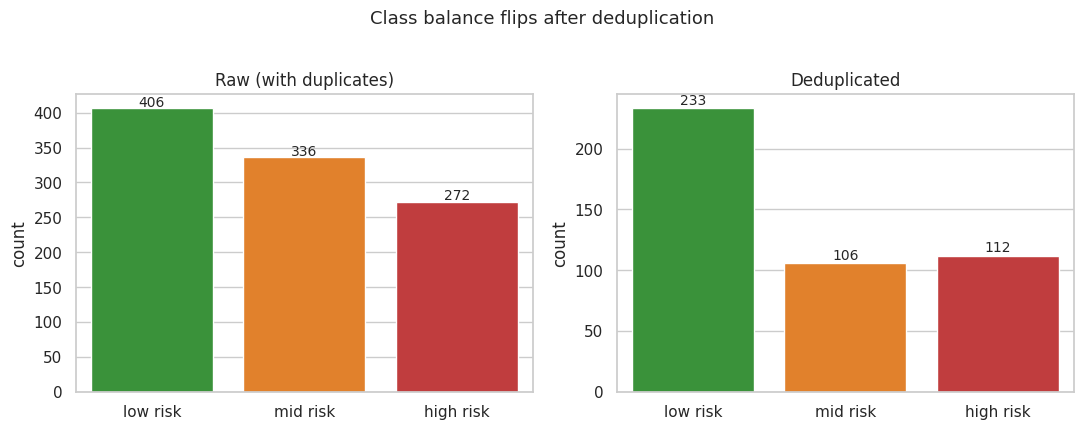

In [2]:
raw_counts = raw["RiskLevel"].value_counts().reindex(RISK_ORDER)
clean_counts = clean["RiskLevel"].value_counts().reindex(RISK_ORDER)
balance = pd.DataFrame({"raw (1014)": raw_counts, "dedup (451)": clean_counts})
balance["dup_removed"] = balance["raw (1014)"] - balance["dedup (451)"]
balance["dup_rate_%"] = (balance["dup_removed"] / balance["raw (1014)"] * 100).round(1)
print(balance)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, col, title in zip(ax, ["raw (1014)", "dedup (451)"], ["Raw (with duplicates)", "Deduplicated"]):
    sns.barplot(x=RISK_ORDER, y=balance[col].values, hue=RISK_ORDER, palette=PALETTE,
                legend=False, ax=a)
    a.set_title(title); a.set_ylabel("count"); a.set_xlabel("")
    for i, v in enumerate(balance[col].values):
        a.text(i, v + 3, str(int(v)), ha="center", fontsize=10)
fig.suptitle("Class balance flips after deduplication", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(PLOTS / "01_class_balance_raw_vs_dedup.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Feature distributions

Histograms of the six vital-sign features on the deduplicated set. Note the right-skew of
`BS` (blood sugar) with a tail of high-glucose cases, the multimodal blood-pressure
readings (clustered around clinical cut-points), and `BodyTemp` concentrated at ~98 °F
with a small fever tail.

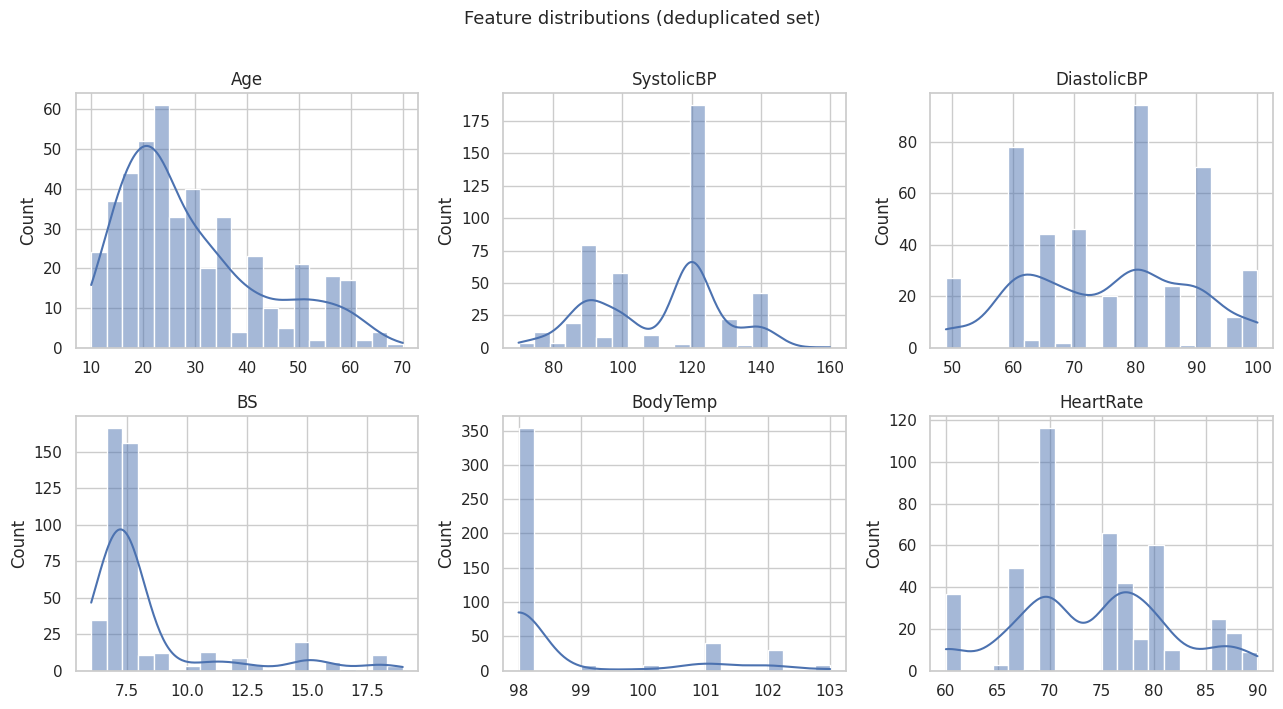

,count,mean,std,min,25%,50%,75%,max
Age,451.0,29.22,13.77,10.0,19.0,25.0,35.0,70.0
SystolicBP,451.0,110.53,17.89,70.0,90.0,120.0,120.0,160.0
DiastolicBP,451.0,75.42,13.77,49.0,65.0,80.0,87.0,100.0
BS,451.0,8.35,2.83,6.0,6.9,7.5,7.9,19.0
BodyTemp,451.0,98.69,1.41,98.0,98.0,98.0,98.0,103.0
HeartRate,451.0,74.10,7.53,60.0,70.0,76.0,80.0,90.0


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.histplot(clean[f], kde=True, ax=ax, color="#4c72b0", bins=20)
    ax.set_title(f); ax.set_xlabel("")
fig.suptitle("Feature distributions (deduplicated set)", fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(PLOTS / "02_feature_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
clean[FEATURES].describe().T.round(2)

## 3. Correlation heatmap

Pearson correlations among features and the ordinal risk level (`risk_encoded`:
low0/mid1/high2). Blood sugar and the two blood-pressure readings show the strongest
positive association with risk — consistent with the literature on this dataset.

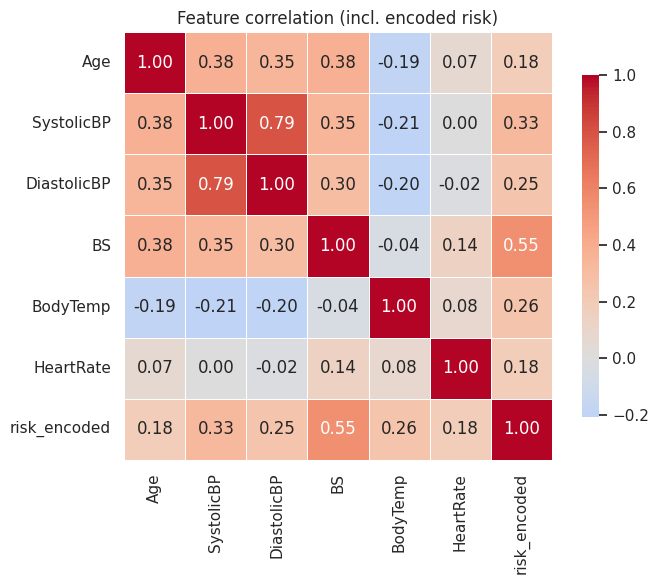

Correlation with risk_encoded (sorted):
BS             0.549
SystolicBP     0.329
BodyTemp       0.259
DiastolicBP    0.254
HeartRate      0.182
Age            0.181
Name: risk_encoded, dtype: float64


In [4]:
corr_df = clean[FEATURES + ["risk_encoded"]].corr()
plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Feature correlation (incl. encoded risk)")
plt.tight_layout(); plt.savefig(PLOTS / "03_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Correlation with risk_encoded (sorted):")
print(corr_df["risk_encoded"].drop("risk_encoded").sort_values(ascending=False).round(3))

## 4. Feature values by risk level

Boxplots of each feature split by risk class. Blood sugar, systolic and diastolic BP rise
clearly with risk; age rises modestly; body temperature and heart rate separate the
classes weakly. This previews which features the classifiers and SHAP should rank highest.

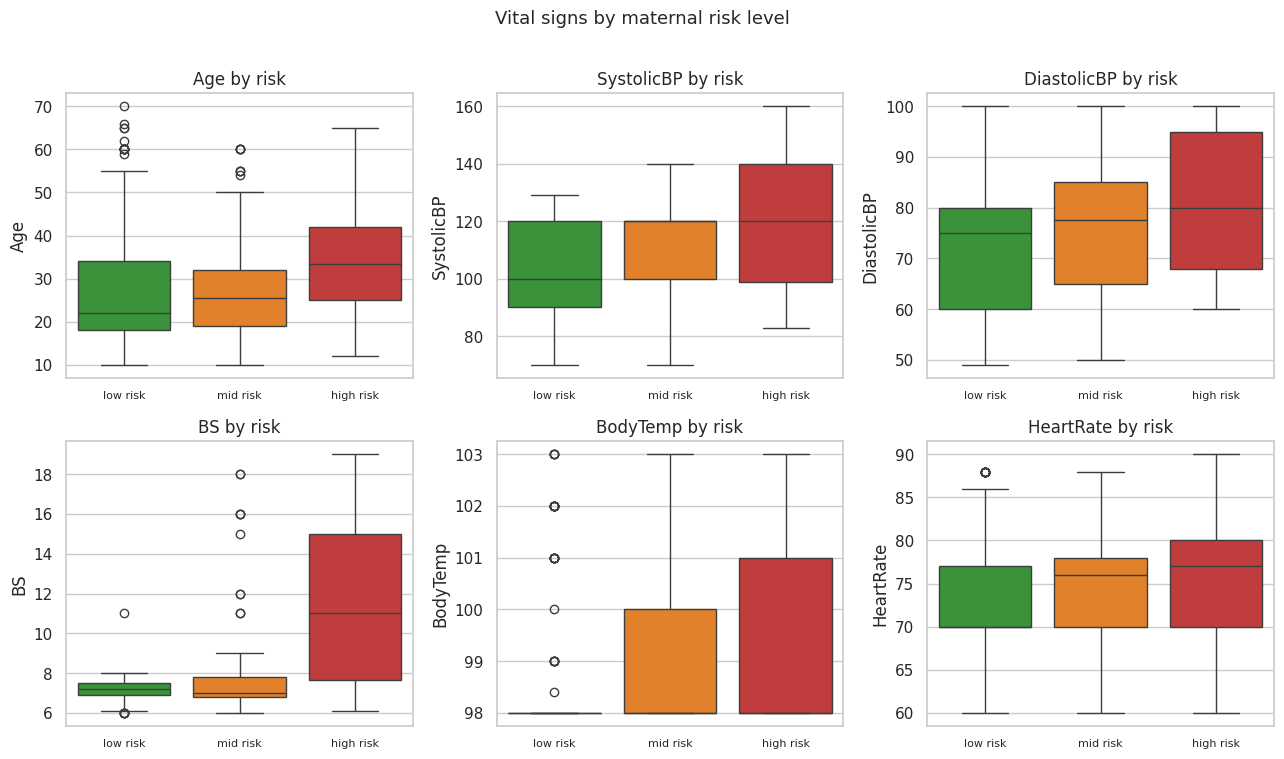

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=clean, x="RiskLevel", y=f, hue="RiskLevel", order=RISK_ORDER,
                palette=PALETTE, legend=False, ax=ax)
    ax.set_title(f"{f} by risk"); ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Vital signs by maternal risk level", fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(PLOTS / "04_boxplots_by_risk.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Key feature relationships

A scatter of the two strongest risk-associated vitals (blood sugar vs systolic BP), coloured
by risk, shows high-risk cases concentrating in the high-BS / high-BP corner — the kind of
joint pattern the association-rule mining (notebook 04) will formalise.

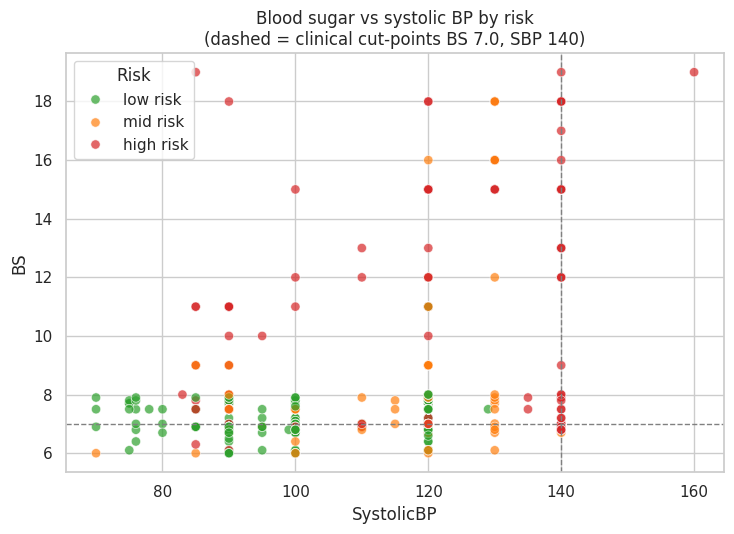

In [6]:
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=clean, x="SystolicBP", y="BS", hue="RiskLevel", hue_order=RISK_ORDER,
                palette=PALETTE, alpha=.7, s=45)
plt.axhline(7.0, ls="--", c="gray", lw=1); plt.axvline(140, ls="--", c="gray", lw=1)
plt.title("Blood sugar vs systolic BP by risk\n(dashed = clinical cut-points BS 7.0, SBP 140)")
plt.legend(title="Risk", loc="upper left")
plt.tight_layout(); plt.savefig(PLOTS / "05_bs_vs_sbp_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Data-quality audit: duplicates & conflicting labels

Two artefacts shape the methodology:
1. **Duplicates** — 562 exact duplicate rows in the raw data (removed before splitting).
2. **Conflicting labels** — distinct feature patterns that appear with *more than one*
   risk label. These are irreducible noise: no model can be right on all copies, so they
   place a ceiling on achievable accuracy. We quantify them here.

In [7]:
# Conflicting-label patterns: same 6 features, >1 distinct RiskLevel (on raw, deduplicated rows)
raw_dedup = raw.drop_duplicates()
labels_per_pattern = raw_dedup.groupby(FEATURES)["RiskLevel"].nunique()
conflicting = labels_per_pattern[labels_per_pattern > 1]
n_conf_patterns = conflicting.shape[0]
n_conf_rows = raw_dedup.groupby(FEATURES).filter(lambda g: g["RiskLevel"].nunique() > 1).shape[0]
print(f"Exact duplicate rows (raw)      : {int(raw.duplicated().sum())}")
print(f"Unique feature+label rows       : {raw_dedup.shape[0]}")
print(f"Conflicting-label patterns      : {n_conf_patterns}")
print(f"Rows involved in conflicts      : {n_conf_rows}")
print(f"Approx. accuracy ceiling impact : ~{n_conf_rows}/{raw_dedup.shape[0]} = {n_conf_rows/raw_dedup.shape[0]:.1%} of unique rows are ambiguous")

Exact duplicate rows (raw)      : 562
Unique feature+label rows       : 452
Conflicting-label patterns      : 35
Rows involved in conflicts      : 71
Approx. accuracy ceiling impact : ~71/452 = 15.7% of unique rows are ambiguous


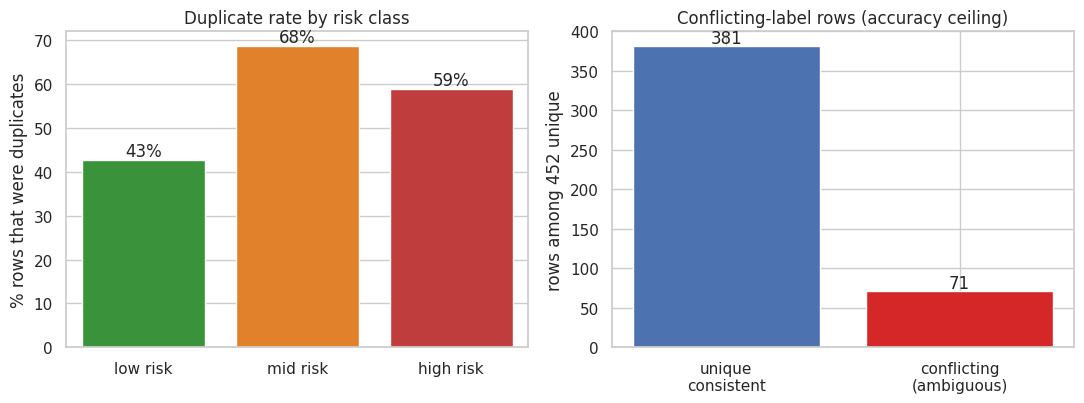

In [8]:
# Visualise: duplicate rate per class + conflicting share
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(x=RISK_ORDER, y=balance["dup_rate_%"].values, hue=RISK_ORDER, palette=PALETTE,
            legend=False, ax=ax[0])
ax[0].set_title("Duplicate rate by risk class"); ax[0].set_ylabel("% rows that were duplicates")
for i, v in enumerate(balance["dup_rate_%"].values):
    ax[0].text(i, v + 1, f"{v:.0f}%", ha="center")

ax[1].bar(["unique\nconsistent", "conflicting\n(ambiguous)"],
          [raw_dedup.shape[0] - n_conf_rows, n_conf_rows], color=["#4c72b0", "#d62728"])
ax[1].set_title("Conflicting-label rows (accuracy ceiling)")
ax[1].set_ylabel("rows among 452 unique")
for i, v in enumerate([raw_dedup.shape[0] - n_conf_rows, n_conf_rows]):
    ax[1].text(i, v + 4, str(v), ha="center")
plt.tight_layout(); plt.savefig(PLOTS / "06_dataquality_audit.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Statistical tests — normality & group differences

Following the comparative study on this dataset (Uddin & Karim, 2025), we add two
inferential checks that justify our modelling choices:

1. **Normality (Shapiro–Wilk + Kolmogorov–Smirnov)** with skewness/kurtosis — if the
   vitals are non-normal, parametric one-way ANOVA is inappropriate and a **non-parametric**
   test of group differences is the correct tool.
2. **Kruskal–Wallis H-test** — a non-parametric test of whether each vital differs across
   the three risk groups. A significant result (p < 0.05) confirms the feature carries
   real signal separating low/mid/high risk.

All tests run on the **deduplicated** set, so the conclusions are not distorted by the
repeated rows that inflate the published results (see §6 and notebook 03).

In [9]:
from scipy import stats

# Normality test + shape statistics per feature (deduplicated set)
norm_rows = []
for f in FEATURES:
    x = clean[f].values
    w, p_sw = stats.shapiro(x)
    # KS against a fitted normal (standardise first)
    d, p_ks = stats.kstest((x - x.mean()) / x.std(ddof=0), "norm")
    norm_rows.append({
        "feature": f,
        "skewness": stats.skew(x),
        "kurtosis": stats.kurtosis(x),          # excess kurtosis (0 = normal)
        "Shapiro_W": w, "Shapiro_p": p_sw,
        "KS_D": d, "KS_p": p_ks,
        "normal?": "no" if p_sw < 0.05 else "yes",
    })
normality = pd.DataFrame(norm_rows).set_index("feature").round(4)
print("Normality tests (deduplicated set):")
print(normality)
print("\nAll features reject normality (p < 0.05) -> non-parametric tests are appropriate.")

Normality tests (deduplicated set):
             skewness  kurtosis  Shapiro_W  Shapiro_p    KS_D  KS_p normal?
feature                                                                    
Age            0.9164   -0.1062     0.9027        0.0  0.1661   0.0      no
SystolicBP    -0.1677   -0.8696     0.9078        0.0  0.2651   0.0      no
DiastolicBP   -0.0288   -0.9322     0.9497        0.0  0.1426   0.0      no
BS             2.2520    4.1215     0.6296        0.0  0.3648   0.0      no
BodyTemp       1.7424    1.4489     0.5372        0.0  0.4714   0.0      no
HeartRate      0.0375   -0.5166     0.9550        0.0  0.1638   0.0      no

All features reject normality (p < 0.05) -> non-parametric tests are appropriate.


Kruskal-Wallis test across risk groups (deduplicated set):
       feature  H_statistic  p_value significant
0           BS     106.6504   0.0000         yes
1   SystolicBP      44.7834   0.0000         yes
2     BodyTemp      31.8996   0.0000         yes
3  DiastolicBP      25.5369   0.0000         yes
4          Age      23.1631   0.0000         yes
5    HeartRate      14.4389   0.0007         yes


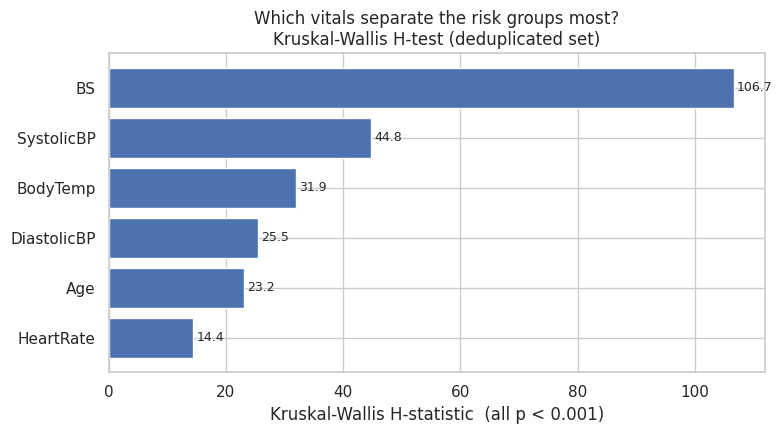

In [10]:
# Kruskal-Wallis H-test: does each vital differ across the 3 risk groups?
groups = {g: clean.loc[clean["RiskLevel"] == g, FEATURES] for g in RISK_ORDER}
kw_rows = []
for f in FEATURES:
    h, p = stats.kruskal(*[groups[g][f].values for g in RISK_ORDER])
    kw_rows.append({"feature": f, "H_statistic": h, "p_value": p,
                    "significant": "yes" if p < 0.05 else "no"})
kw = pd.DataFrame(kw_rows).sort_values("H_statistic", ascending=False).reset_index(drop=True)
print("Kruskal-Wallis test across risk groups (deduplicated set):")
print(kw.round(4))

# Plot the H-statistics (higher = stronger separation between risk groups)
plt.figure(figsize=(8, 4.5))
order = kw.sort_values("H_statistic")
bars = plt.barh(order["feature"], order["H_statistic"], color="#4c72b0")
plt.xlabel("Kruskal-Wallis H-statistic  (all p < 0.001)")
plt.title("Which vitals separate the risk groups most?\nKruskal-Wallis H-test (deduplicated set)")
for b, v in zip(bars, order["H_statistic"]):
    plt.text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(PLOTS / "07_kruskal_wallis.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

- **Class balance flips** with deduplication: mid/high-risk rows were disproportionately
  duplicated, so the deduplicated set is more imbalanced toward low risk → motivates
  `class_weight` and high-risk-recall focus.
- **Blood sugar (BS)** and **systolic/diastolic BP** are the strongest risk-associated
  vitals; `BodyTemp` and `HeartRate` separate classes weakly (and `HeartRate` carries no
  clinical-range variation — excluded from rule mining in notebook 04).
- **Conflicting-label patterns** impose an accuracy ceiling we will reference when
  interpreting classifier performance.
- **Statistical tests** confirm the design: all six vitals are **non-normal**
  (Shapiro–Wilk p < 0.05), so non-parametric methods are appropriate, and the
  **Kruskal–Wallis** test finds every vital differs significantly across the risk groups
  (p < 0.001) — BS and the BP readings separate the groups most strongly, agreeing with the
  correlation and boxplot evidence.

Figures saved to `plots/`. Next: **03_classification**.